# AG-HYPOPT · Trial 08

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Seven trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at objective 0.0803 (0 diverged, gamma finite; mu rel-RMSE 35.9%, gamma rel-RMSE 22.3%), then trial_05 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) at 0.0822, then trial_06 (sw 0.497, h_f 4.0, h_s 3.876, cap 0.104) at 0.0861. All 0 diverged, gamma finite. The best region is now a tight cluster: strong-to-full sigma weight (0.84-0.87), kernels at/near their upper bounds (h_f ~3.9-4.0, h_s ~3.6-3.7), and a small-to-modest gamma cap (~0.1-0.25). Phase 'trials' (trials-informed TPE).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_08'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (7/5 trials)
ID |     ei | params
 1 | 3.9134 | {"gamma_rel_cap": 0.49363842166896277, "h_f_scale": 3.2070585093251087, "h_s_scale": 3.6107577170672753, "sigma_weight": 0.8740627812707711}
 2 | 2.0825 | {"gamma_rel_cap": 0.23948272708135848, "h_f_scale": 1.2142946820667366, "h_s_scale": 0.9769920583911651, "sigma_weight": 0.8505699985986314}
 3 | 3.9957 | {"gamma_rel_cap": 0.2954514258827058, "h_f_scale": 3.985487510961152, "h_s_scale": 3.6238517830981807, "sigma_weight": 0.8685847580364594}
 4 | 3.9837 | {"gamma_rel_cap": 0.09077696868136476, "h_f_scale": 4.0, "h_s_scale": 3.719513840411308, "sigma_weight": 0.8418693418308868}
 5 | 3.6768 | {"gamma_rel_cap": 0.16464468835587692, "h_f_scale": 1.621899680004235, "h_s_scale": 3.649560489177832, "sigma_weight": 0.8314027249820148}
 6 | 3.9920 | {"gamma_rel_cap": 0.17225010105275204, "h_f_scale": 3.8380881028702833, "h_s_scale": 3.6737922917590256, "sigma_weight": 0.8545030739974235}
 7 | 3.8446 | {"gamma_rel_cap": 0.098774

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The best region is a tight cluster: strong-to-full sigma weight (~0.85), kernels near their upper bounds (h_f ~3.9-4.0, h_s ~3.6-3.7) and a small gamma cap. trial_07 (0.0803) holds the optimum. The batch's top-ei draws (ids 3, 6, 4, 8, 1) nearly all sit in this cluster, so the informative choice is the one that varies the least-explored knob inside the region: the gamma cap.

Candidate 3 (ei 3.9957, the highest) stays in the best region (sw 0.869, h_f 3.985, h_s 3.624) but sets a distinctly larger gamma cap (0.295 vs trial_07's 0.107 and trial_05's 0.217), testing whether relaxing the gamma trust region changes the optimum; the other top draws are near-duplicates of trial_07 with little new information.

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # candidate 3: sigma_weight 0.869, h_f_scale 3.985, h_s_scale 3.624, gamma_rel_cap 0.295 (best region, larger cap)


chosen: {'gamma_rel_cap': 0.2954514258827058, 'h_f_scale': 3.985487510961152, 'h_s_scale': 3.6238517830981807, 'sigma_weight': 0.8685847580364594}
Running  1nW Trans05 ... 

μ 9.39 -> 5.93 | γ 8.5 -> 5.47 | NLL 0.24


Running  1nW Trans20 ... 

μ 17.32 -> 27.71 | γ 8.5 -> 5.43 | NLL 0.66


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 63.43 | γ 14.1 -> 13.96 | NLL 0.71


Running 3nW Trans100 ... 

μ 175.71 -> 97.37 | γ 14.1 -> 13.76 | NLL 0.69



Total: 7.6 min


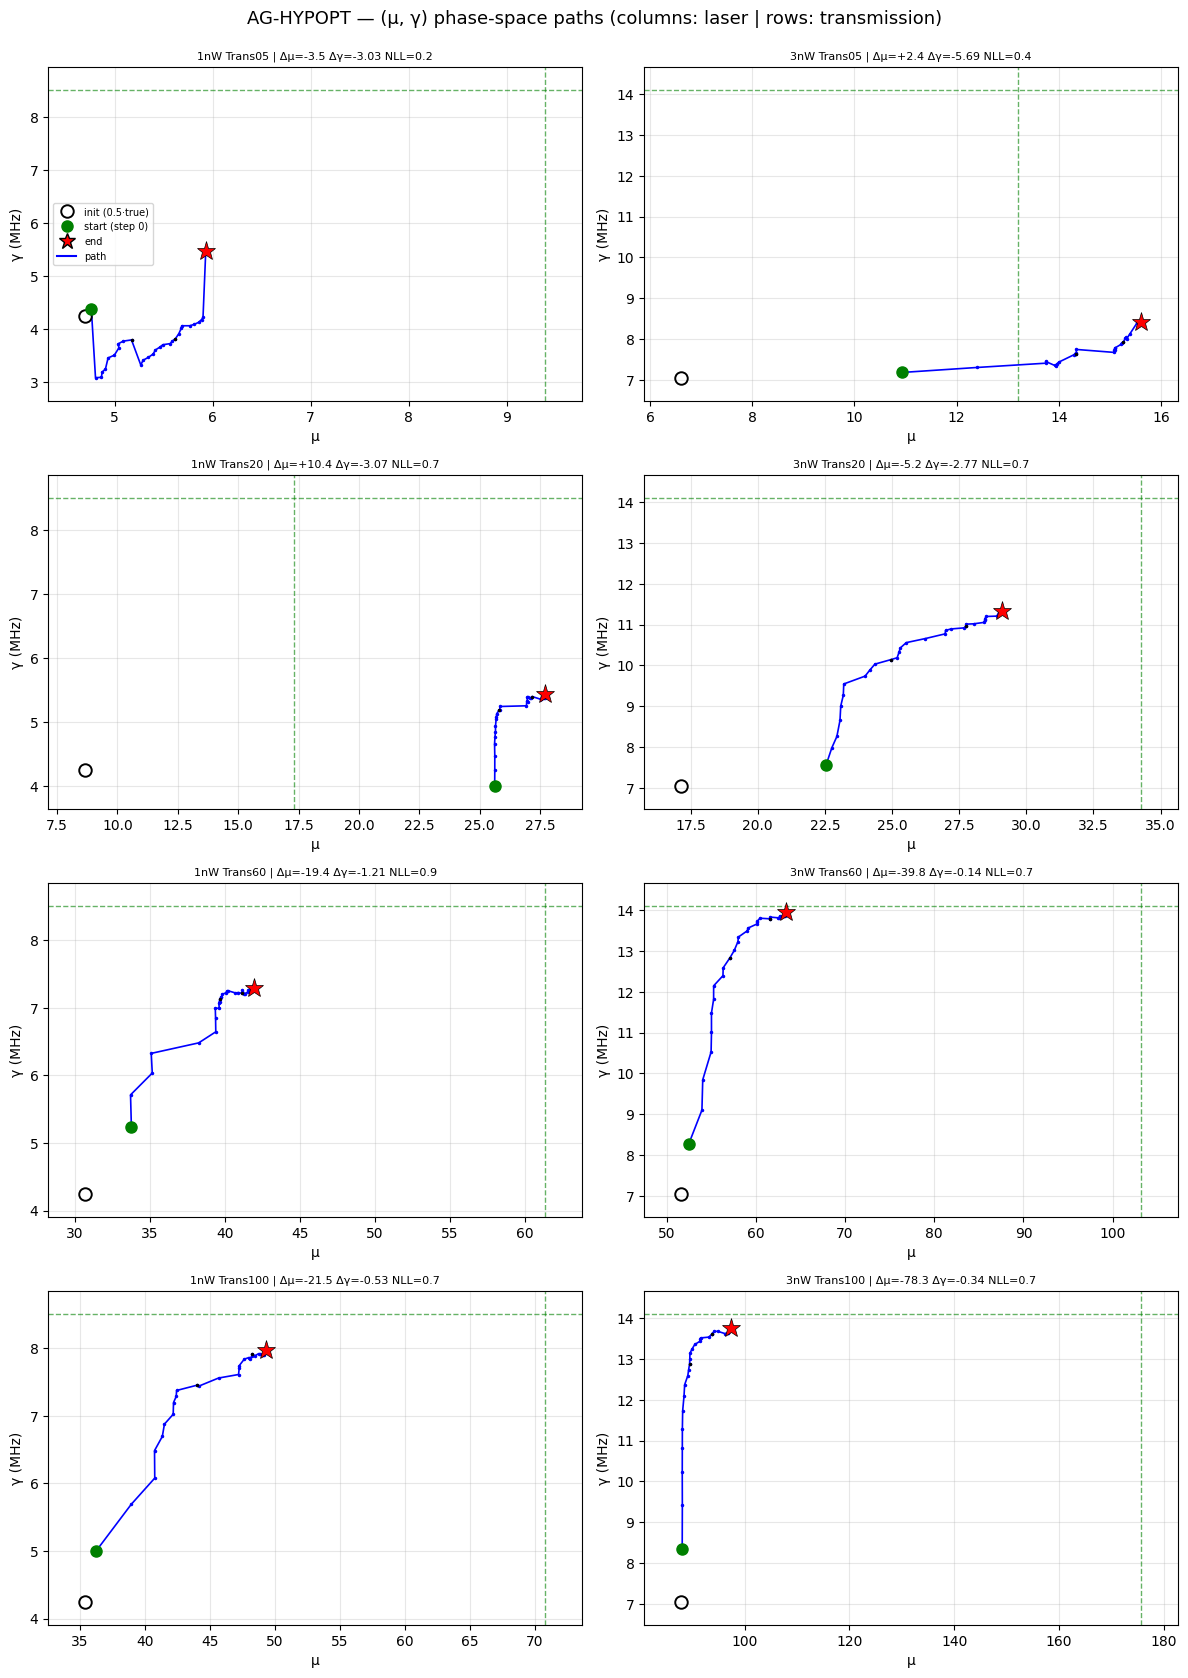

trial finished in 7.6 min
objective = 0.0876 ± 0.0238
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.93   -36.9 |     8.50    5.47   -35.6
1nW Trans20       17.32   27.71   +60.0 |     8.50    5.43   -36.1
1nW Trans60       61.37   41.93   -31.7 |     8.50    7.29   -14.2
1nW Trans100       70.82   49.32   -30.4 |     8.50    7.97    -6.2
3nW Trans05       13.20   15.62   +18.3 |    14.10    8.41   -40.3
3nW Trans20       34.28   29.11   -15.1 |    14.10   11.33   -19.6
3nW Trans60      103.20   63.43   -38.5 |    14.10   13.96    -1.0
3nW Trans100      175.71   97.37   -44.6 |    14.10   13.76    -2.4

weighted objective (T-graded, cap=1.0) = 0.0876 | diverged cells: 0
μ: RMSE 32.999 (rel 37.0%, bias -19.360) | γ: RMSE 2.748 (rel 24.6%, bias -2.095)


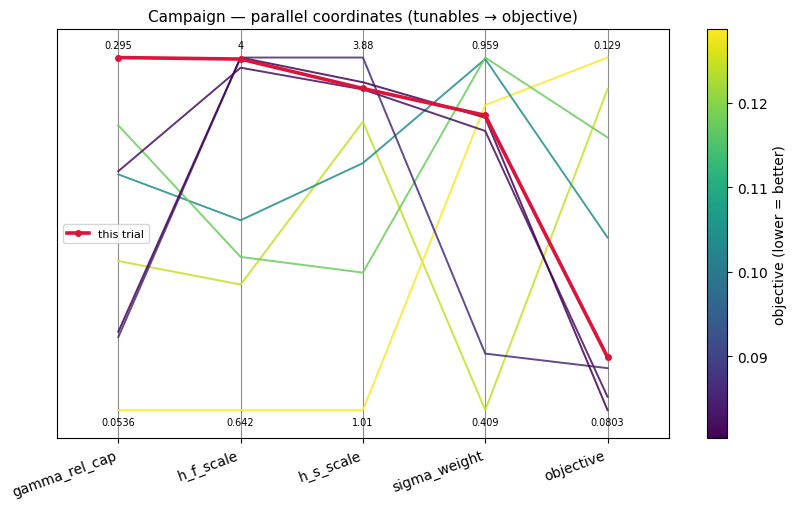

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 08 (sw 0.869, h_f 3.985, h_s 3.624, cap 0.295) ran to completion in 7.6 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0876 +/- 0.0238 - worse than trial_07 (0.0803), trial_05 (0.0822) and trial_06 (0.0861), so fourth best.

mu rel-RMSE 37.0% (slightly worse than trial_07's 35.9%): same shape - high-T undershoot (3nW Trans100 -44.6%, 3nW Trans60 -38.5%, 1nW Trans60 -31.7%, 1nW Trans100 -30.4%) and low-T overshoot (1nW Trans20 +60.0%, 3nW Trans05 +18.3%); bias -19.36.

gamma rel-RMSE 24.6% (worse than trial_07's 22.3%): low T under-estimated (3nW Trans05 -40.3%, 1nW Trans20 -36.1%, 1nW Trans05 -35.6%) and high T near truth (-1.0%, -2.4%).

This candidate was the top-ei draw and sat almost exactly on trial_07's kernel/sigma design (sw 0.869 vs 0.865, h_f 3.985 vs 4.0, h_s 3.624 vs 3.675), differing mainly in a much larger gamma cap (0.295 vs 0.107). The objective rose, so inside the best region a smaller gamma trust region is preferred.

**Summary:** Trial 08 (sw=0.869, h_f=3.985, h_s=3.624, cap=0.295) finished in 7.6 min with 0 diverged cells and gamma finite, objective 0.0876 +/- 0.0238 - worse than trial_07 (mu rel-RMSE 37.0%, gamma rel-RMSE 24.6%).
**Key insight:** In the best kernel/sigma region, a larger gamma cap (0.295 vs trial_07's 0.107) worsened the objective (0.0876 vs 0.0803), so a small gamma trust region is preferred.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 08 (sw=0.869, h_f=3.985, h_s=3.624, cap=0.295): objective 0.0876 +/- 0.0238 - worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 37.0%, gamma rel-RMSE 24.6%).'
KEY_INSIGHT = 'In the best kernel/sigma region, a larger gamma cap (0.295 vs trial_07 0.107) worsened the objective (0.0876 vs 0.0803), so a small gamma trust region is preferred.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_08 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_09.ipynb. Open it and follow its cells from the top.
